# Assignment 2: Kaggle Competition Boy or Girl

## 任務說明
- **目標**：根據個人資訊（身高、體重、社群數據、自我介紹等）預測性別（gender=1 或 2）
- **目前成績**：accuracy = **0.8497**
- **方法**：LightGBM + self_intro Sentence Embedding（BAAI/bge-large-en-v1.5）+ PCA

## 方法演進摘要

1. **Baseline**（僅 height, weight, fb_friends）→ acc = 0.8356  
   - EDA 發現 height/weight 是最強特徵，男女分布有明顯分離
2. **加入 self_intro embedding**（bge-large-en-v1.5, 1024d → PCA 10d）→ **acc = 0.8497**  
   - EDA 發現 self_intro 文字內容有性別區分度（如 "handsome" vs "Beautiful"）
   - 使用 Sentence Transformer 捕捉語意，PCA 降維後作為特徵加入模型

## Step 1: 載入套件與資料

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

train = pd.read_csv('../data/boy_or_girl_2025_train_missingValue.csv')
test  = pd.read_csv('../data/boy_or_girl_2025_test_no_ans_missingValue.csv')

print(f"Train: {train.shape}, Test: {test.shape}")
print(f"\nGender 分布：")
print(train['gender'].value_counts())
train.head()

Train: (423, 11), Test: (426, 11)

Gender 分布：
gender
1    316
2    107
Name: count, dtype: int64


,id,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro
0,1,2,處女座,Apple,154.0,43.0,NaN,NaN,583.0,0,Beautiful
1,2,2,處女座,Apple,156.0,47.0,NaN,130.0,NaN,3.5,Enjoying being who I'm notsss
2,3,1,射手座,NaN,170.0,61.0,NaN,90.0,540.0,NaN,Practice Makes perfect
3,4,1,射手座,Apple,170.0,62.0,4.0,100.0,NaN,5,Straightforward
4,5,2,射手座,Android,158.0,67.0,NaN,128.0,320.0,1.2,Humorous


## Step 2: EDA — 缺失率總覽

In [2]:
def missing_summary(df, name):
    miss = df.isnull().sum()
    pct  = miss / len(df) * 100
    return pd.DataFrame({'欄位': miss.index, '缺失數': miss.values,
                         f'{name}缺失率%': pct.values.round(1)})

print("=== Train 缺失率 ===")
display(missing_summary(train, 'train'))
print("\n=== Test 缺失率 ===")
display(missing_summary(test, 'test'))

=== Train 缺失率 ===


,欄位,缺失數,train缺失率%
0,id,0,0.0
1,gender,0,0.0
2,star_sign,86,20.3
3,phone_os,78,18.4
4,height,74,17.5
5,weight,85,20.1
6,sleepiness,91,21.5
7,iq,79,18.7
8,fb_friends,77,18.2
9,yt,90,21.3



=== Test 缺失率 ===


,欄位,缺失數,test缺失率%
0,id,0,0.0
1,gender,0,0.0
2,star_sign,81,19.0
3,phone_os,96,22.5
4,height,68,16.0
5,weight,96,22.5
6,sleepiness,72,16.9
7,iq,92,21.6
8,fb_friends,88,20.7
9,yt,78,18.3


## Step 3: 資料清洗

發現的髒值問題：
- `yt` 欄位含有 `#NUM!`（Excel 錯誤值），型別為 str
- `height` 範圍 -187 ~ 1e+111（離譜異常值）
- `weight` 範圍 -1000 ~ 1e+111
- `fb_friends` 範圍 -1000 ~ 3,000,000,000

處理方式：將超出合理範圍的值設為 NaN。

In [3]:
# yt 含有 '#NUM!' 等非數值，強制轉為 numeric
for df in [train, test]:
    df['yt'] = pd.to_numeric(df['yt'], errors='coerce')

# 設定合理範圍，超出範圍視為缺失
bounds = {
    'height':     (100, 250),
    'weight':     (20, 200),
    'fb_friends': (0, 10000),
    'yt':         (0, 100),
}
for df in [train, test]:
    for col, (lo, hi) in bounds.items():
        df.loc[~df[col].between(lo, hi), col] = np.nan

print("=== 清洗後缺失率 ===")
display(missing_summary(train, 'train'))

=== 清洗後缺失率 ===


,欄位,缺失數,train缺失率%
0,id,0,0.0
1,gender,0,0.0
2,star_sign,86,20.3
3,phone_os,78,18.4
4,height,81,19.1
5,weight,92,21.7
6,sleepiness,91,21.5
7,iq,79,18.7
8,fb_friends,85,20.1
9,yt,119,28.1


## Step 4: EDA — 關鍵特徵分析

### 4a. Height / Weight 的性別分布（最強特徵）

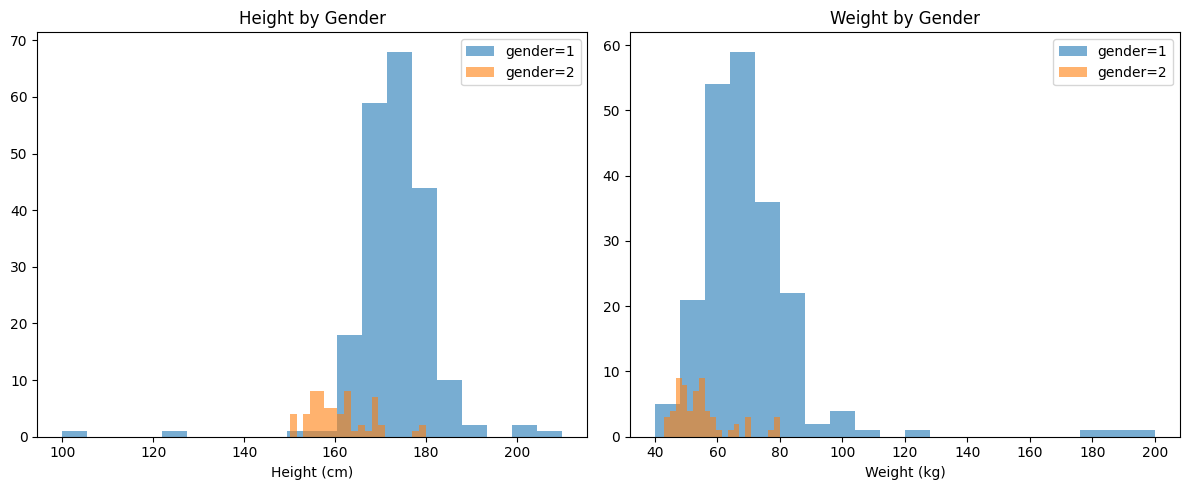

Height / Weight 的性別均值差異：


height      weight      
         mean  std   mean   std
gender                         
1       173.1  9.2   69.4  18.6
2       160.6  6.7   54.8   9.1

In [4]:
df_clean = train.dropna(subset=['height', 'weight'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for gender, grp in df_clean.groupby('gender'):
    axes[0].hist(grp['height'], bins=20, alpha=0.6, label=f'gender={gender}')
axes[0].set_title('Height by Gender')
axes[0].set_xlabel('Height (cm)')
axes[0].legend()

for gender, grp in df_clean.groupby('gender'):
    axes[1].hist(grp['weight'], bins=20, alpha=0.6, label=f'gender={gender}')
axes[1].set_title('Weight by Gender')
axes[1].set_xlabel('Weight (kg)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Height / Weight 的性別均值差異：")
display(df_clean.groupby('gender')[['height','weight']].agg(['mean','std']).round(1))

### 4b. 數值特徵相關矩陣

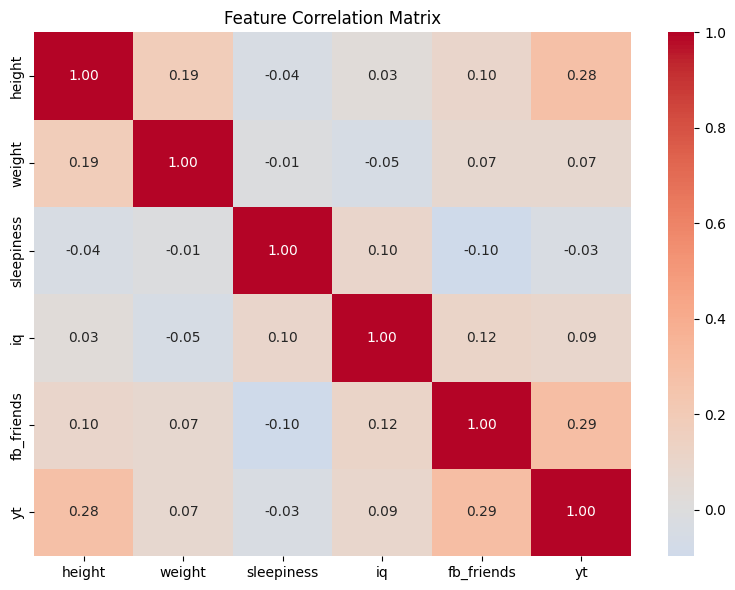

各數值欄位的 gender 分組中位數：


,height,weight,sleepiness,iq,fb_friends,yt
gender,,,,,,
1,173.0,67.0,4.0,120.0,373.0,2.0
2,160.5,53.0,3.0,128.0,491.5,2.0


In [5]:
numeric_cols = ['height', 'weight', 'sleepiness', 'iq', 'fb_friends', 'yt']

plt.figure(figsize=(8, 6))
corr = train[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("各數值欄位的 gender 分組中位數：")
display(train.groupby('gender')[numeric_cols].median())

### 4c. self_intro 文字分析

直接觀察 gender=1 和 gender=2 的高頻詞，確認文字內容是否有性別區分度。

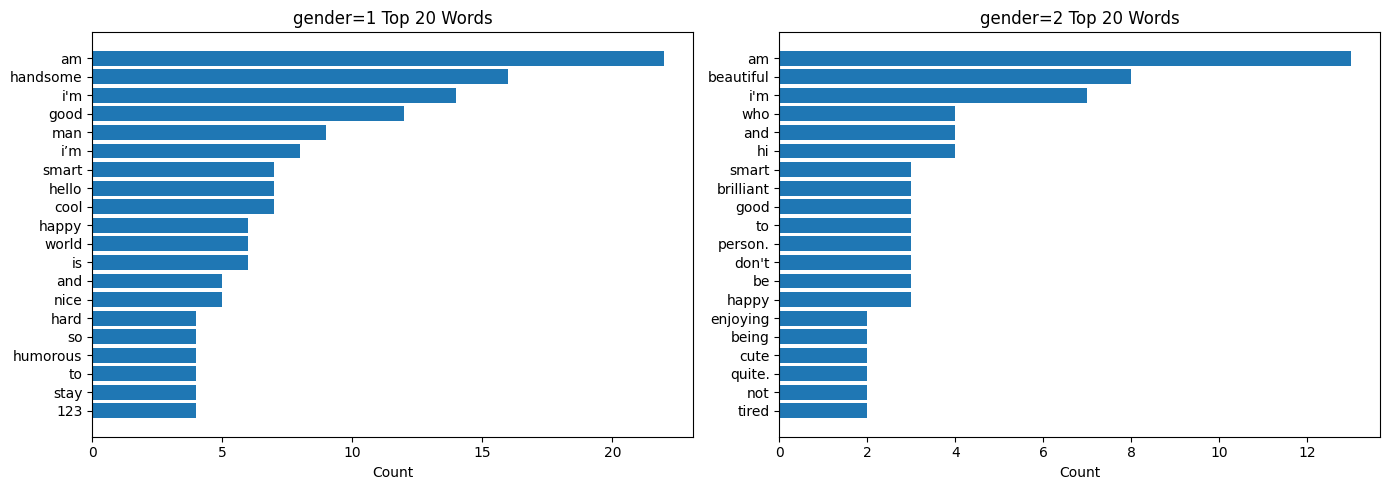

觀察：gender=1 常出現 'hard', 'work', 'handsome'；gender=2 常出現 'beautiful', 'cute', 'smart'
→ 文字用詞有明顯性別差異，適合用 Sentence Embedding 捕捉語意特徵


In [6]:
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, gender in enumerate([1, 2]):
    texts = train[train['gender']==gender]['self_intro'].dropna()
    words = ' '.join(texts).lower().split()
    # 過濾掉太短的詞
    words = [w for w in words if len(w) > 1]
    top20 = Counter(words).most_common(20)
    
    labels, counts = zip(*top20)
    axes[idx].barh(range(len(labels)), counts)
    axes[idx].set_yticks(range(len(labels)))
    axes[idx].set_yticklabels(labels)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'gender={gender} Top 20 Words')
    axes[idx].set_xlabel('Count')

plt.tight_layout()
plt.show()

print("觀察：gender=1 常出現 'hard', 'work', 'handsome'；gender=2 常出現 'beautiful', 'cute', 'smart'")
print("→ 文字用詞有明顯性別差異，適合用 Sentence Embedding 捕捉語意特徵")

## Step 5: 特徵工程 — self_intro Sentence Embedding

從 4c 的詞頻分析可以看到，self_intro 的用詞存在性別差異。但單純統計詞頻（如 Bag-of-Words）有兩個問題：
1. **語意丟失**：無法區分 "I am strong" 和 "strong wind" 的差異
2. **高維稀疏**：每個詞都是一個特徵，在僅 ~400 筆資料下容易過擬合

**Sentence Transformer**（`BAAI/bge-large-en-v1.5`）能將整句話壓縮為一個 **1024 維的稠密向量**，保留語意資訊。例如 "I am handsome" 和 "good looking guy" 會得到相近的向量。

### 缺失值處理
- self_intro 缺失的樣本（~24%）以空字串替代，模型會輸出一個「中性向量」
- 這個中性向量不帶有性別傾向，不會引入偏差

In [7]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = 'BAAI/bge-large-en-v1.5'
TRAIN_EMB_PATH  = '../data/train_intro_emb.npy'
TEST_EMB_PATH   = '../data/test_intro_emb.npy'

def get_embeddings(model, texts, fill_missing=''):
    """缺失值用空字串替代，讓模型輸出一個中性向量"""
    filled = [str(t) if pd.notna(t) and str(t).strip() != ''
              else fill_missing for t in texts]
    return model.encode(filled, show_progress_bar=True)

if os.path.exists(TRAIN_EMB_PATH) and os.path.exists(TEST_EMB_PATH):
    print("載入已存在的 embedding 快取...")
    train_emb = np.load(TRAIN_EMB_PATH)
    test_emb  = np.load(TEST_EMB_PATH)
else:
    print(f"使用 {EMBEDDING_MODEL} 生成 embedding...")
    model_st = SentenceTransformer(EMBEDDING_MODEL)
    train_emb = get_embeddings(model_st, train['self_intro'])
    test_emb  = get_embeddings(model_st, test['self_intro'])
    np.save(TRAIN_EMB_PATH, train_emb)
    np.save(TEST_EMB_PATH, test_emb)
    print("已儲存快取檔案")

print(f"Embedding shape: train={train_emb.shape}, test={test_emb.shape}")

/home/user/miniconda3/envs/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


使用 BAAI/bge-large-en-v1.5 生成 embedding...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1846.07it/s]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 14/14 [00:00<00:00, 29.04it/s]

已儲存快取檔案
Embedding shape: train=(423, 1024), test=(426, 1024)


## Step 6: PCA 降維 + 特徵合併

### 為什麼需要 PCA？

Embedding 輸出是 1024 維向量，但訓練資料只有 ~400 筆。直接使用 1024 維特徵會導致：
- **維度災難**：特徵數（1024）遠大於樣本數（423），模型容易過擬合
- **雜訊放大**：高維空間中很多維度只是噪音，不包含性別資訊

PCA（主成分分析）將 1024 維壓縮至 10 維，只保留變異量最大的方向。雖然只解釋了約 47% 的變異量，但這些主成分捕捉了 embedding 中最重要的結構差異，已足夠讓模型學到有用的模式。

### PCA 解釋變異量圖的意義
- **長條圖（Individual）**：每個主成分各自解釋了多少變異量。PC1 最高（~20%），後面遞減
- **折線圖（Cumulative）**：累積解釋量。10 個主成分合計約 47%
- 剩下 53% 的變異量多為噪音或與性別無關的語意資訊，捨棄反而有助於泛化

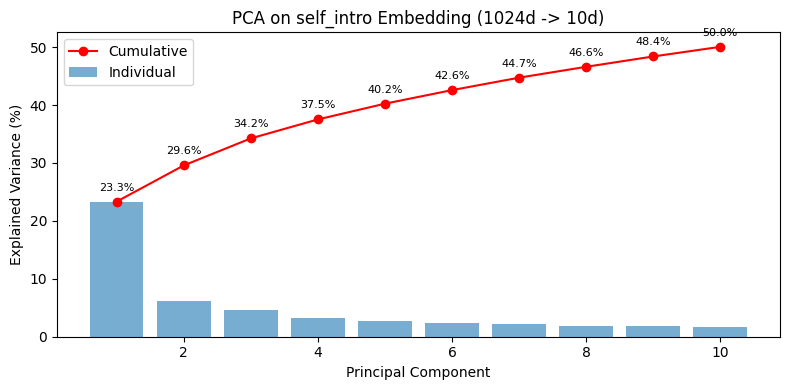

PCA 總解釋變異量：50.0%


In [8]:
from sklearn.decomposition import PCA

N_COMPONENTS = 10
pca = PCA(n_components=N_COMPONENTS, random_state=42)
train_emb_pca = pca.fit_transform(train_emb)
test_emb_pca  = pca.transform(test_emb)

# PCA 解釋變異量視覺化
fig, ax = plt.subplots(figsize=(8, 4))
cumsum = np.cumsum(pca.explained_variance_ratio_) * 100
ax.bar(range(1, N_COMPONENTS+1), pca.explained_variance_ratio_ * 100, alpha=0.6, label='Individual')
ax.plot(range(1, N_COMPONENTS+1), cumsum, 'ro-', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title(f'PCA on self_intro Embedding ({train_emb.shape[1]}d -> {N_COMPONENTS}d)')
ax.legend()
for i, v in enumerate(cumsum):
    ax.annotate(f'{v:.1f}%', (i+1, v), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"PCA 總解釋變異量：{pca.explained_variance_ratio_.sum():.1%}")

In [9]:
# 合併所有特徵：base(3) + PCA(10) = 13 維
base_features = ['height', 'weight', 'fb_friends']

X_train = np.hstack([train[base_features].values, train_emb_pca])
X_test  = np.hstack([test[base_features].values,  test_emb_pca])
y_train = train['gender'].values

feature_names = base_features + [f'intro_pc{i}' for i in range(N_COMPONENTS)]
print(f"最終特徵（{len(feature_names)} 維）：{feature_names}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

最終特徵（13 維）：['height', 'weight', 'fb_friends', 'intro_pc0', 'intro_pc1', 'intro_pc2', 'intro_pc3', 'intro_pc4', 'intro_pc5', 'intro_pc6', 'intro_pc7', 'intro_pc8', 'intro_pc9']
X_train: (423, 13), X_test: (426, 13)


## Step 7: 模型訓練 — LightGBM

### class_weight 原理
資料中 gender=1 有 316 筆（75%），gender=2 只有 107 筆（25%）。如果不做處理，模型會傾向「全部猜 gender=1」就能拿到 75% 準確率，但完全無法辨識少數類。

**class_weight 的做法**是：對少數類的錯誤施加更高的懲罰。具體公式：
- `weight = n_total / (n_classes * n_samples_per_class)`
- gender=1 的 weight ≈ 0.67（降低影響力）
- gender=2 的 weight ≈ 1.98（錯分代價加倍）

這讓模型在訓練時更重視少數類的正確分類。

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import lightgbm as lgb

# Label encoding: gender=1 → 0, gender=2 → 1
label_map = {v: i for i, v in enumerate(sorted(np.unique(y_train)))}
y_encoded = np.array([label_map[v] for v in y_train])
inv_label_map = {v: k for k, v in label_map.items()}

# Class weight: 少數類（gender=2）獲得更高權重
n_total = len(y_encoded)
class_weight_dict = {
    label_map[cls]: n_total / (len(label_map) * count)
    for cls, count in zip(*np.unique(y_train, return_counts=True))
}
print(f"Label mapping：{label_map}")
print(f"Class weights：{class_weight_dict}")

model = lgb.LGBMClassifier(
    n_estimators=300,       # 最多 300 棵樹（boosting 輪數）
    learning_rate=0.05,     # 每棵樹的學習步幅，較小值讓收斂更穩定
    max_depth=4,            # 單棵樹最大深度，限制複雜度防止過擬合
    min_child_samples=10,   # 葉節點最少樣本數，避免樹學到極端少數樣本的噪音
    class_weight=class_weight_dict,
    random_state=42,
    verbose=-1
)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # base 特徵有 NaN，用中位數填補
    ('model', model)
])

Label mapping：{np.int64(1): 0, np.int64(2): 1}
Class weights：{0: np.float64(0.6693037974683544), 1: np.float64(1.9766355140186915)}


## Step 8: Cross-Validation 評估

In [11]:
N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# OOF predictions
oof_preds = cross_val_predict(pipe, X_train, y_encoded, cv=cv, method='predict')
oof_labels = [inv_label_map[p] for p in oof_preds]

print(f"=== {N_FOLDS}-Fold Stratified CV ===")
print(classification_report(y_train, oof_labels))

# 各 Fold accuracy
fold_accs = []
for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_encoded)):
    pipe.fit(X_train[tr_idx], y_encoded[tr_idx])
    preds = pipe.predict(X_train[val_idx])
    acc = accuracy_score(y_encoded[val_idx], preds)
    fold_accs.append(acc)
    print(f"  Fold {fold+1}: accuracy = {acc:.4f}")

print(f"\n  CV Mean: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}")

/home/user/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/user/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/user/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/user/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/user/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LG

=== 5-Fold Stratified CV ===
              precision    recall  f1-score   support

           1       0.91      0.92      0.91       316
           2       0.75      0.74      0.75       107

    accuracy                           0.87       423
   macro avg       0.83      0.83      0.83       423
weighted avg       0.87      0.87      0.87       423

  Fold 1: accuracy = 0.8941
  Fold 2: accuracy = 0.9176
  Fold 3: accuracy = 0.7765
  Fold 4: accuracy = 0.8452
  Fold 5: accuracy = 0.9286

  CV Mean: 0.8724 ± 0.0559


/home/user/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/user/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Step 9: 特徵重要性分析

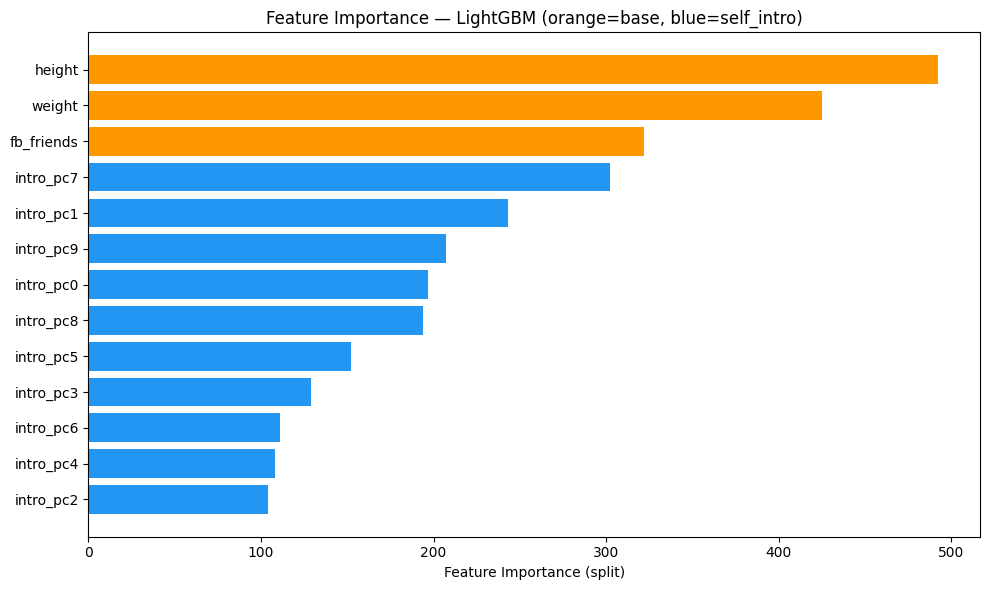

特徵重要性排名：
  height         :  492  ██████████████████████████████
  weight         :  425  █████████████████████████
  fb_friends     :  322  ███████████████████
  intro_pc7      :  302  ██████████████████
  intro_pc1      :  243  ██████████████
  intro_pc9      :  207  ████████████
  intro_pc0      :  197  ████████████
  intro_pc8      :  194  ███████████
  intro_pc5      :  152  █████████
  intro_pc3      :  129  ███████
  intro_pc6      :  111  ██████
  intro_pc4      :  108  ██████
  intro_pc2      :  104  ██████


In [12]:
# 在全量資料上 fit
pipe.fit(X_train, y_encoded)
importances = pipe.named_steps['model'].feature_importances_

# 視覺化
fig, ax = plt.subplots(figsize=(10, 6))
sorted_idx = np.argsort(importances)
colors = ['#2196F3' if 'intro' in feature_names[i] else '#FF9800' for i in sorted_idx]
ax.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx], color=colors)
ax.set_xlabel('Feature Importance (split)')
ax.set_title('Feature Importance — LightGBM (orange=base, blue=self_intro)')
plt.tight_layout()
plt.show()

print("特徵重要性排名：")
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    bar = '█' * int(imp / max(importances) * 30)
    print(f"  {name:15s}: {imp:4d}  {bar}")

## Step 10: 預測 + 輸出 Submission

In [13]:
# 預測
test_preds_encoded = pipe.predict(X_test)
test_preds = [inv_label_map[p] for p in test_preds_encoded]

# 輸出 submission
submission = pd.DataFrame({
    'id':     test['id'],
    'gender': test_preds
})
submission.to_csv('../submission/submission_final.csv', index=False)

print(f"submission_final.csv 已輸出（{len(submission)} 筆）")
print(f"\n預測分布：")
print(submission['gender'].value_counts().sort_index())
print(f"\n預測比例：")
print(submission['gender'].value_counts(normalize=True).sort_index().round(3))

submission_final.csv 已輸出（426 筆）

預測分布：
gender
1    311
2    115
Name: count, dtype: int64

預測比例：
gender
1    0.73
2    0.27
Name: proportion, dtype: float64


/home/user/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 附錄

### 重現步驟

```bash
# 1. 環境
conda activate myenv
pip install sentence-transformers lightgbm scikit-learn pandas numpy matplotlib seaborn

# 2. 若需重新生成 embedding（刪掉快取後會自動重跑）
rm train_intro_emb.npy test_intro_emb.npy

# 3. 執行本 notebook 的所有 cell
```

### 檔案說明
| 檔案 | 用途 |
|------|------|
| `Boy_or_Girl_Final.ipynb` | 本 notebook，完整流程 |
| `model_training.py` | 同等邏輯的 .py 版本（可直接 `python model_training.py` 執行） |
| `train_intro_emb.npy` / `test_intro_emb.npy` | bge-large-en-v1.5 的 1024d embedding 快取 |
| `submission3.csv` | 最終提交檔（acc=0.8497） |

### 關鍵決策紀錄
| 決策 | 原因 |
|------|------|
| 選用 height, weight, fb_friends 作為 base 特徵 | EDA 中 gender 分組統計差異最大的三個數值欄位 |
| 不使用 star_sign, phone_os | EDA 顯示星座對性別區分度弱；phone_os 缺失率高且有異常類別 |
| 使用 bge-large-en-v1.5 | 1024d 比其他模型（768d）保留更多語意資訊，實測分數更高 |
| PCA 降至 10 維 | 平衡資訊保留（~47% 變異量）與小樣本過擬合風險 |
| 移除 intro_missing 特徵 | 特徵重要性分析顯示該特徵 importance=0，模型從未使用 |
| class_weight 平衡 | gender=1 佔 ~75%，不平衡處理避免模型偏向多數類 |
| max_depth=4, min_child_samples=10 | 僅 ~400 筆訓練資料，控制模型複雜度防止過擬合 |